In [ ]:
from google.colab import files
files.upload()

In [ ]:

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d mirichoi0218/insurance

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
100% 16.0k/16.0k [00:00<00:00, 32.3MB/s]



In [ ]:
!unzip insurance.zip

Archive:  insurance.zip
  inflating: insurance.csv           


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['font.size'] =14
plt.rcParams['font.weight']= 'bold'
#plt.style.use('seaborn-whitegrid')

In [ ]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


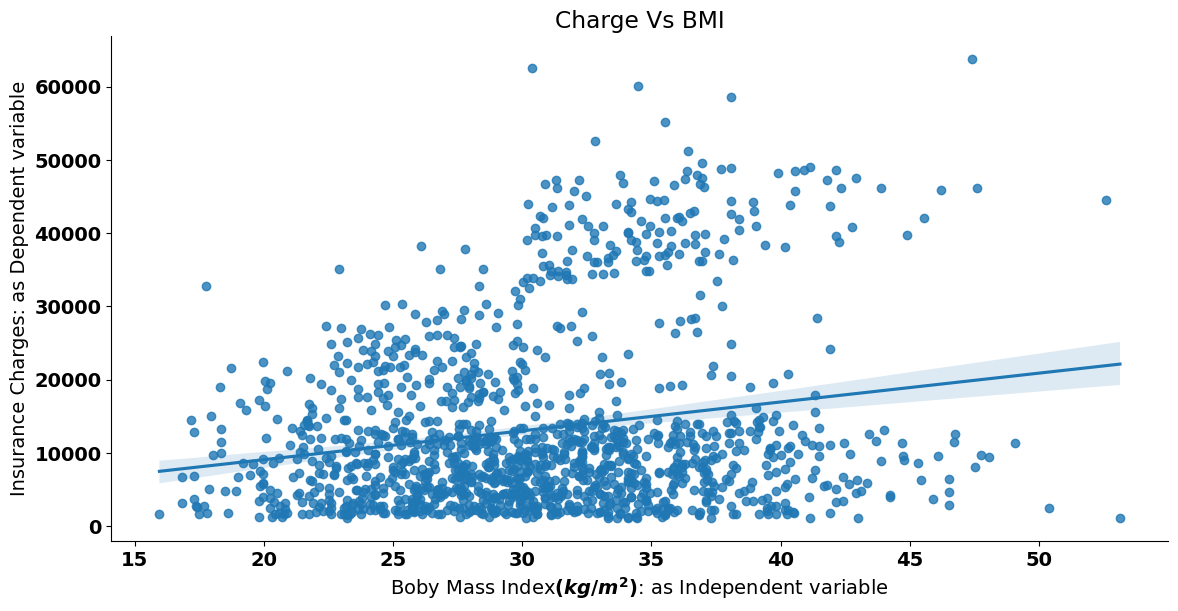

In [ ]:
sns.lmplot(x='bmi',y='charges',data=df,aspect=2,height=6)
plt.xlabel('Boby Mass Index$(kg/m^2)$: as Independent variable')
plt.ylabel('Insurance Charges: as Dependent variable')
plt.title('Charge Vs BMI');

In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


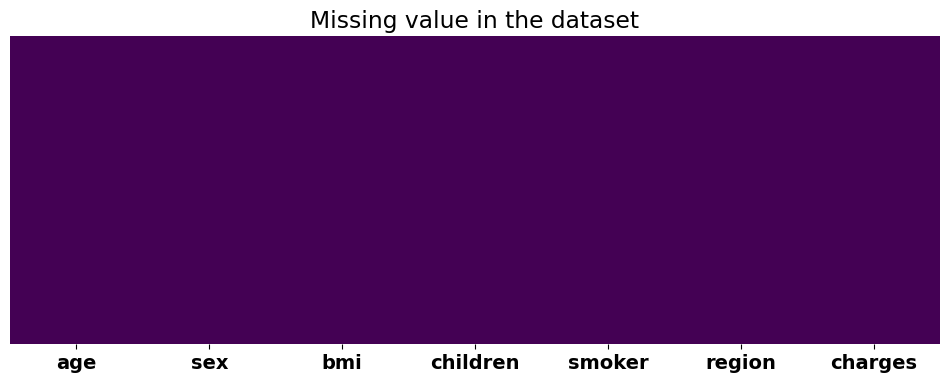

In [ ]:
plt.figure(figsize=(12,4))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis',yticklabels=False)
plt.title('Missing value in the dataset');

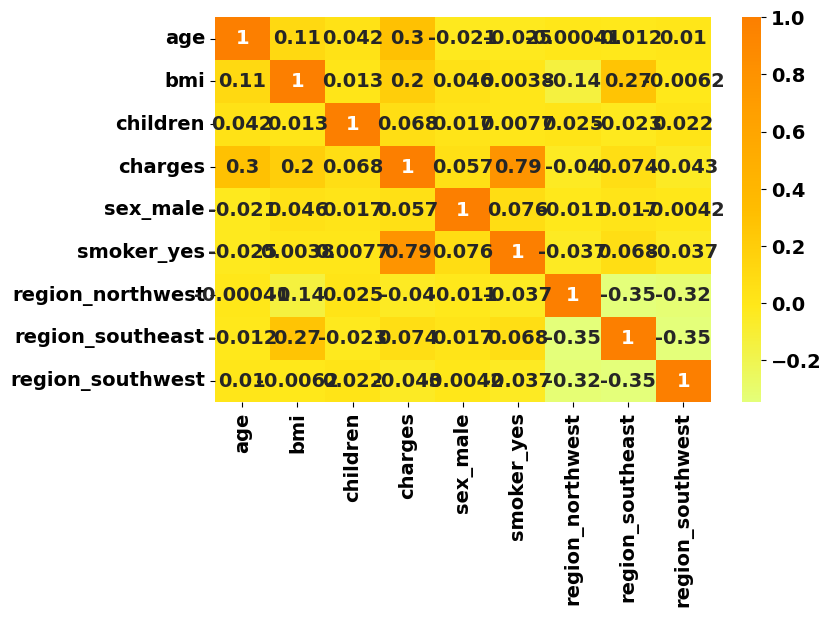

In [ ]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
corr = df_encoded.corr()
sns.heatmap(corr, cmap = 'Wistia', annot= True);

/tmp/ipykernel_495/1119713767.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'],bins=50,color='r',ax=ax)
/tmp/ipykernel_495/1119713767.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log10(df['charges']),bins=40,color='b',ax=ax)


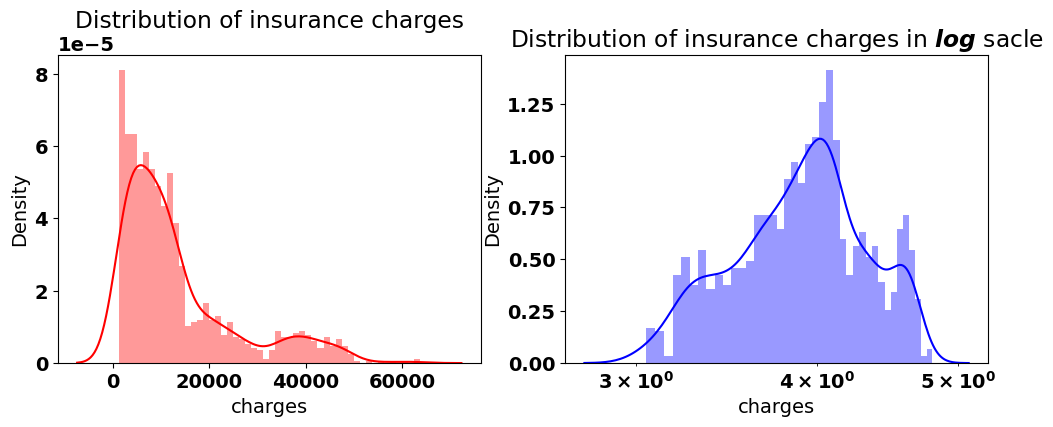

In [ ]:
f= plt.figure(figsize=(12,4))

ax=f.add_subplot(121)
sns.distplot(df['charges'],bins=50,color='r',ax=ax)
ax.set_title('Distribution of insurance charges')

ax=f.add_subplot(122)
sns.distplot(np.log10(df['charges']),bins=40,color='b',ax=ax)
ax.set_title('Distribution of insurance charges in $log$ sacle')
ax.set_xscale('log');

/tmp/ipykernel_495/1961728721.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='sex', y='charges',data=df,palette='Wistia',ax=ax)
/tmp/ipykernel_495/1961728721.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='smoker', y='charges',data=df,palette='magma',ax=ax)


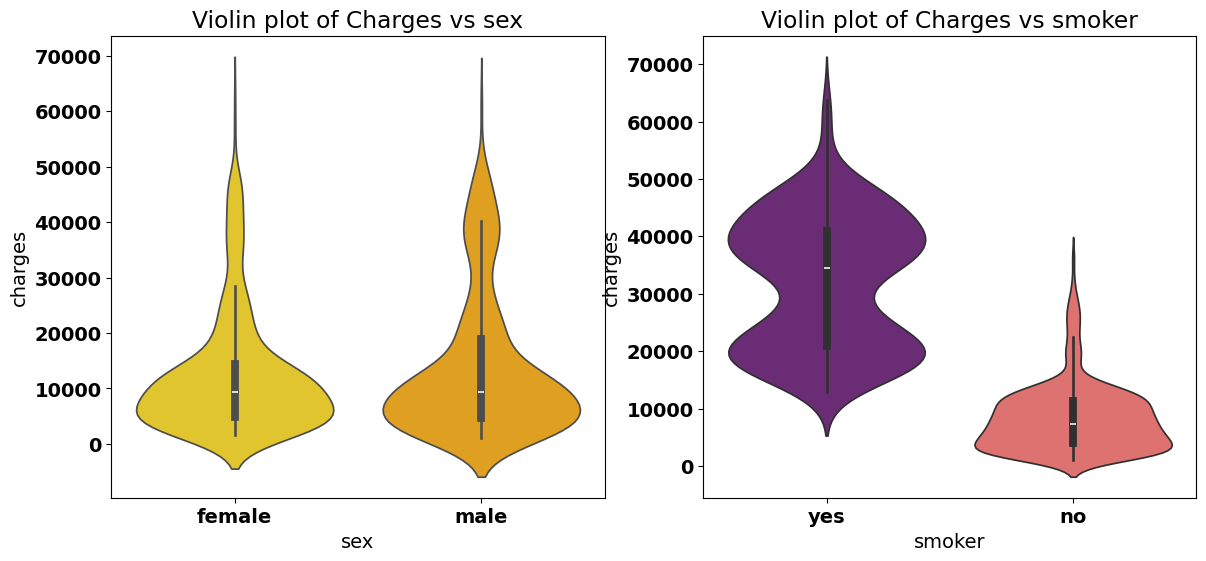

In [ ]:
f = plt.figure(figsize=(14,6))
ax = f.add_subplot(121)
sns.violinplot(x='sex', y='charges',data=df,palette='Wistia',ax=ax)
ax.set_title('Violin plot of Charges vs sex')

ax = f.add_subplot(122)
sns.violinplot(x='smoker', y='charges',data=df,palette='magma',ax=ax)
ax.set_title('Violin plot of Charges vs smoker');

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X , y = df_encoded.drop('charges',axis=1), df_encoded['charges']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X.shape)
print(y.shape)
print(X_test.shape)

(1338, 8)
(1338,)
(268, 8)


In [ ]:
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print(f"w : ", lin_reg_model.coef_)
print(f"b : ", lin_reg_model.intercept_)

w :  [ 2.56975706e+02  3.37092552e+02  4.25278784e+02 -1.85916916e+01
  2.36511289e+04 -3.70677326e+02 -6.57864297e+02 -8.09799354e+02]
b :  -11931.21905032666


In [ ]:
y_predict = lin_reg_model.predict(X_test)

In [ ]:
sklearn_mse = mean_squared_error(y_test, y_predict)
sklearn_rmse = np.sqrt(sklearn_mse)
sklearn_r2 = r2_score(y_test, y_predict)

print(f"MSE: {sklearn_mse}")
print(f"RMSE: {sklearn_r2}")

MSE: 33596915.85136145
RMSE: 0.7835929767120724


### Biểu đồ dữ liệu huấn luyện và đường hồi quy (BMI vs Charges)

Biểu đồ này thể hiện mối quan hệ giữa chỉ số BMI và chi phí bảo hiểm trong tập dữ liệu huấn luyện, với các đường hồi quy riêng cho người hút thuốc và không hút thuốc.

<Figure size 1000x700 with 0 Axes>

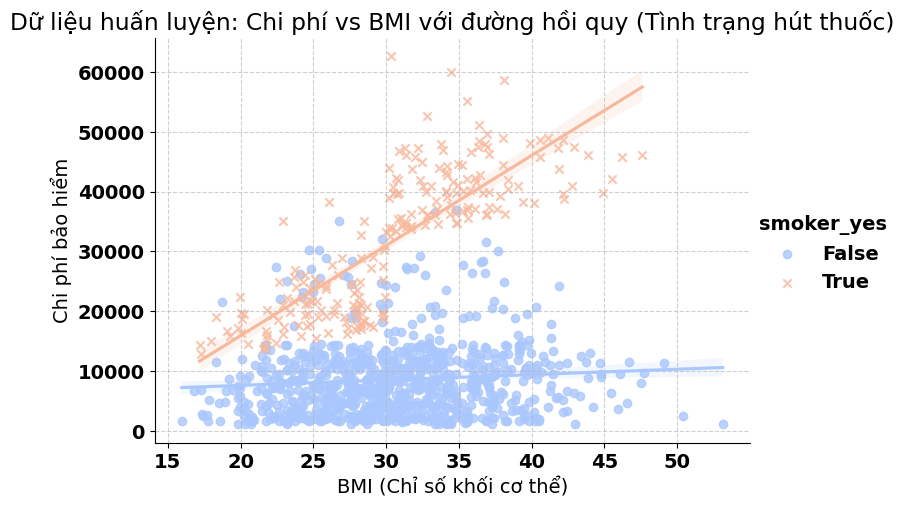

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame from X_train and y_train for plotting
train_df_for_plot = X_train.copy()
train_df_for_plot['charges'] = y_train

# Plot the relationship between bmi and charges for the training data,
# distinguishing by smoker status, and add regression lines.
plt.figure(figsize=(10, 7))
sns.lmplot(x='bmi', y='charges', hue='smoker_yes', data=train_df_for_plot,
           markers=['o', 'x'], palette='coolwarm', aspect=1.5, height=5)
plt.title('Dữ liệu huấn luyện: Chi phí vs BMI với đường hồi quy (Tình trạng hút thuốc)')
plt.xlabel('BMI (Chỉ số khối cơ thể)')
plt.ylabel('Chi phí bảo hiểm')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Biểu đồ chi phí thực tế so với chi phí dự đoán trên tập huấn luyện

Biểu đồ này so sánh chi phí bảo hiểm thực tế với chi phí dự đoán bởi mô hình trên tập huấn luyện. Đường chéo màu đỏ ($y=x$) đại diện cho một dự đoán hoàn hảo.

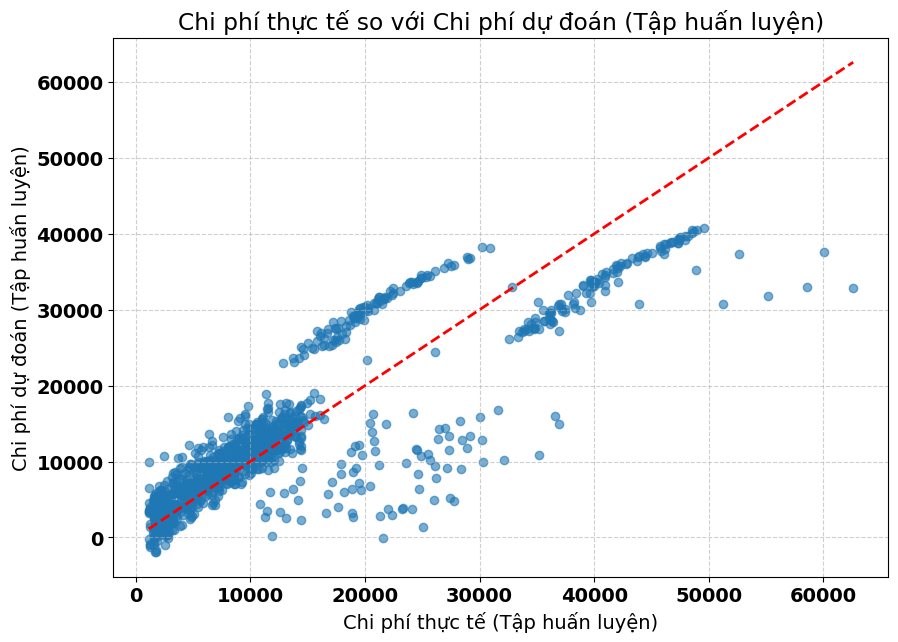

In [ ]:
# Predict on the training data
y_train_predict = lin_reg_model.predict(X_train)

# Plot actual vs predicted values for the training set
plt.figure(figsize=(10, 7))
plt.scatter(y_train, y_train_predict, alpha=0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2) # y=x line
plt.xlabel('Chi phí thực tế (Tập huấn luyện)')
plt.ylabel('Chi phí dự đoán (Tập huấn luyện)')
plt.title('Chi phí thực tế so với Chi phí dự đoán (Tập huấn luyện)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Biểu đồ dữ liệu kiểm tra và đường hồi quy (BMI vs Charges)

Biểu đồ này thể hiện mối quan hệ giữa chỉ số BMI và chi phí bảo hiểm trong tập dữ liệu kiểm tra, với các đường hồi quy riêng cho người hút thuốc và không hút thuốc.

<Figure size 1000x700 with 0 Axes>

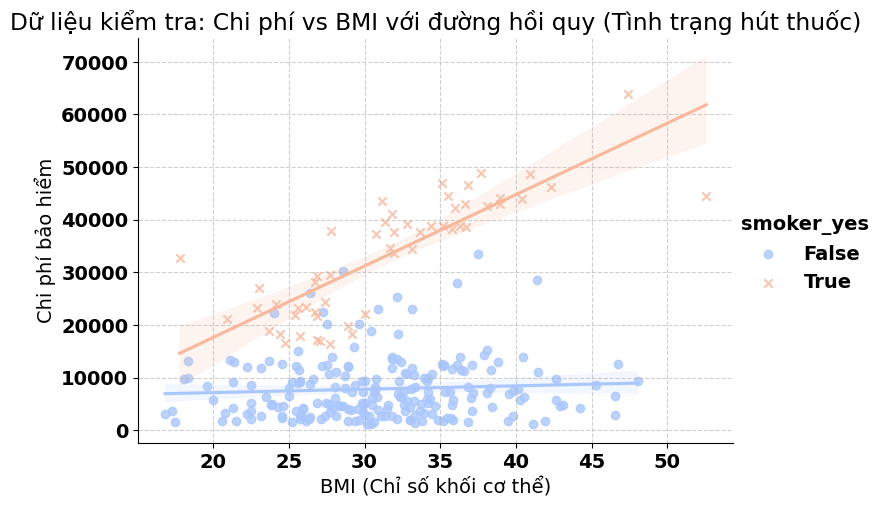

In [ ]:
# Create a DataFrame from X_test and y_test for plotting
test_df_for_plot = X_test.copy()
test_df_for_plot['charges'] = y_test

# Plot the relationship between bmi and charges for the test data,
# distinguishing by smoker status, and add regression lines.
plt.figure(figsize=(10, 7))
sns.lmplot(x='bmi', y='charges', hue='smoker_yes', data=test_df_for_plot,
           markers=['o', 'x'], palette='coolwarm', aspect=1.5, height=5)
plt.title('Dữ liệu kiểm tra: Chi phí vs BMI với đường hồi quy (Tình trạng hút thuốc)')
plt.xlabel('BMI (Chỉ số khối cơ thể)')
plt.ylabel('Chi phí bảo hiểm')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Biểu đồ chi phí thực tế so với chi phí dự đoán trên tập kiểm tra

Biểu đồ này so sánh chi phí bảo hiểm thực tế với chi phí dự đoán bởi mô hình trên tập kiểm tra. Đường chéo màu đỏ ($y=x$) đại diện cho một dự đoán hoàn hảo.

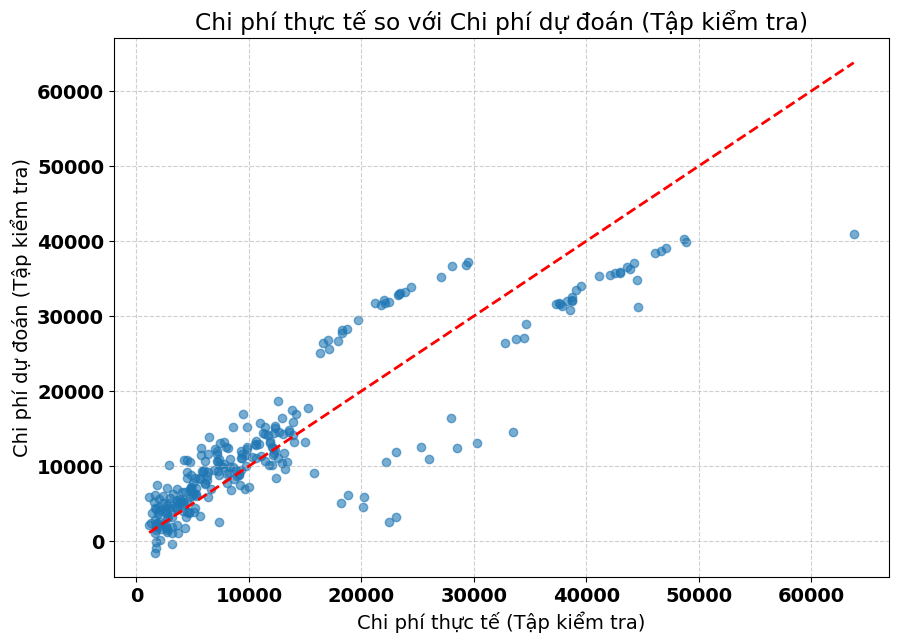

In [ ]:
# Plot actual vs predicted values for the test set
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_predict, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # y=x line
plt.xlabel('Chi phí thực tế (Tập kiểm tra)')
plt.ylabel('Chi phí dự đoán (Tập kiểm tra)')
plt.title('Chi phí thực tế so với Chi phí dự đoán (Tập kiểm tra)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()